# 05 — From chips to a map

**Question this notebook answers:** does any of this survive contact with a real
Sentinel-2 scene?

Everything so far ran on a curated benchmark: 27,000 pre-cut, pre-resampled,
pre-cleaned 64×64 chips. This chapter fetches actual imagery from a public
catalogue, handles the mess — mixed resolutions, clouds, a different processing
level — runs the classifier across the whole scene, and writes a **georeferenced
GeoTIFF** that opens in QGIS.

**Produces:** `outputs/landcover_prediction.tif`, per-class areas in hectares,
figures `05_*.png`, and the domain-shift analysis that is the most valuable part
of the chapter.

**Expected runtime:** ~25 minutes on a Colab T4 without the SAM section, ~40 with
it.

### Environment setup and persistence

On Colab this clones the repository, installs the pinned dependencies, and — the
part that matters — mounts Google Drive so that **outputs survive the session**.
Locally it is a no-op beyond putting `src/` on the path.

**Why Drive.** A Colab VM is deleted when the session ends, and the notebooks
depend on each other's artefacts: 01 writes the split and normalisation
statistics, 02 writes the model checkpoint that 04, 05 and 06 all load. Without
persistence, a disconnect means re-running earlier chapters. So `outputs/` and
`figures/` are redirected to Drive via environment variables read by
`s2map.config` at import time.

**`data/` is deliberately NOT on Drive.** The EuroSAT cache is ~2.9 GB and every
training epoch reads it randomly; Drive is a network mount and random reads
through it are slow enough to dominate the runtime. Re-downloading into the
local VM disk each session costs a few minutes and is the faster trade. Set
`USE_DRIVE = False` to keep everything ephemeral.

The install is wrapped so a fragile wheel prints a clear message instead of
killing the kernel halfway through a 40-minute session.

**Re-running this cell picks up code changes.** It hard-resets the clone to
`origin/main` and purges `s2map` from `sys.modules`, because Python caches
imported modules: without the purge, a `git pull` updates the file on disk while
the kernel keeps running the old code, and you get an `AttributeError` for a
function that is visibly there in the source. The clone is treated as a
read-only checkout — edit the notebook in Colab or the code locally, not in
`/content/s2-chips-to-map`, since the reset discards changes there.

**If this cell reports a numpy mismatch**, restart the runtime
(*Runtime → Restart session*) and run it again. Colab preinstalls a mutually
consistent numpy/torch/scipy set; when pip replaces one of them on disk, the
kernel is left holding the old version in memory and every compiled extension
raises `ValueError: numpy.dtype size changed`. Only a restart fixes it. The
requirements file uses compatible *ranges* rather than exact pins for exactly
this group of packages, so it should not happen — the check is there because it
is the single most common way a Colab notebook dies.

In [1]:
# --- edit these two if you are running your own fork -----------------------
GITHUB_USER = "SaadH-077"
USE_DRIVE = True          # False -> everything stays in the ephemeral session
# ---------------------------------------------------------------------------

import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "s2-chips-to-map"

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        PERSIST = Path("/content/drive/MyDrive/s2-chips-to-map")
        for sub in ("outputs", "figures"):
            (PERSIST / sub).mkdir(parents=True, exist_ok=True)
        # Read by s2map.config at import time, so this must happen before the import below.
        os.environ["S2MAP_OUTPUT_DIR"] = str(PERSIST / "outputs")
        os.environ["S2MAP_FIGURE_DIR"] = str(PERSIST / "figures")
        print("persisting outputs and figures to", PERSIST)

    if not Path(REPO).exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/{GITHUB_USER}/{REPO}.git"], check=False)
    if Path(REPO).exists():
        os.chdir(REPO)
        # Pick up fixes without needing a fresh VM: a stale clone from an earlier
        # session is otherwise invisible and confusing. --depth 1 clones are
        # shallow, so unshallow first or the pull fails on a diverged history.
        subprocess.run(["git", "fetch", "--quiet", "--depth", "50", "origin", "main"], check=False)
        before = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        subprocess.run(["git", "reset", "--hard", "--quiet", "origin/main"], check=False)
        after = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        if before != after:
            print(f"repo updated {before[:7]} -> {after[:7]}")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    except subprocess.CalledProcessError as exc:
        print("!! dependency install failed:", exc)
        print("!! continuing anyway — the cells below will report what is missing")

ROOT = Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Drop any already-imported s2map modules before importing them again. Python
# caches modules in sys.modules, so a `git pull` that updates a file on disk has
# NO effect on a kernel that already imported it — you get
# `AttributeError: module 's2map.bands' has no attribute ...` for a function you
# can plainly see in the source. Purging here means re-running this one cell is
# enough to pick up new code, without restarting the runtime and losing state.
_stale = [m for m in list(sys.modules) if m == "s2map" or m.startswith("s2map.")]
for _mod in _stale:
    del sys.modules[_mod]
if _stale:
    print(f"reloaded {len(_stale)} s2map modules from disk (was: {', '.join(sorted(_stale))})")

from s2map import config as C
C.ensure_dirs()
C.print_environment()
print()
# Catches the one Colab failure mode that no amount of re-running fixes:
# pip replaced numpy on disk after this kernel already imported it.
C.check_environment()
cfg = C.load_config()
SEED = C.set_seed(cfg.seed)
print(f"seed             {SEED}   (multi-seed runs use {cfg.seeds})")
DEVICE = C.get_device()
print(f"device           {DEVICE}")
print(f"outputs ->       {C.OUTPUT_DIR}")
print(f"figures ->       {C.FIGURE_DIR}")
print(f"data cache ->    {C.DATA_DIR}  (local/ephemeral by design — see the note above)")
if DEVICE == "cpu":
    print("\n!! no GPU detected. On Colab: Runtime > Change runtime type > T4 GPU.")

Mounted at /content/drive
persisting outputs and figures to /content/drive/MyDrive/s2-chips-to-map
python           3.12.13 on Linux
numpy            2.0.2
torch            2.11.0+cu128
torchvision      0.26.0+cu128
timm             1.0.9
sklearn          1.6.1
rasterio         1.3.10
open_clip        2.26.1
gpu              Tesla T4 (15.6 GB)
repo root        /content/s2-chips-to-map

environment check  OK (numpy on disk matches numpy in memory)
seed             42   (multi-seed runs use (0, 1, 2))
device           cuda
outputs ->       /content/drive/MyDrive/s2-chips-to-map/outputs
figures ->       /content/drive/MyDrive/s2-chips-to-map/figures
data cache ->    /content/s2-chips-to-map/data  (local/ephemeral by design — see the note above)


### The area of interest

A ~15 × 15 km box over the **Bay of Cádiz, Spain**: open sea, tidal salt marsh,
a river channel, farmland, dense residential districts and an industrial port,
all inside one window. That mix is deliberate — an AOI containing only one land
cover type would make the map look excellent and prove nothing.

Coordinates, dates and the cloud threshold live in `configs/default.yaml`, so
this notebook can be pointed at a different AOI without editing code.

In [2]:
import numpy as np
from s2map import bands as B, data as D, evaluate as E, inference as I, models as M, stac as S, viz as V

V.set_style()
AOI = cfg.aoi
BBOX = tuple(AOI["bbox"])
print(f"AOI          {AOI['name']}")
print(f"bbox         {BBOX}  (lon_min, lat_min, lon_max, lat_max, EPSG:4326)")
print(f"date range   {AOI['date_range']}   max cloud {AOI['max_cloud_cover']}%")

# rough extent in km, for a sanity check on the size of the download
import math
lat_mid = (BBOX[1] + BBOX[3]) / 2
km_x = (BBOX[2] - BBOX[0]) * 111.32 * math.cos(math.radians(lat_mid))
km_y = (BBOX[3] - BBOX[1]) * 110.57
print(f"extent       {km_x:.1f} x {km_y:.1f} km  -> about {km_x * 100:.0f} x {km_y * 100:.0f} pixels at 10 m")

AOI          Bay of Cadiz, Spain
bbox         (-6.3, 36.48, -6.12, 36.62)  (lon_min, lat_min, lon_max, lat_max, EPSG:4326)
date range   2023-06-01/2023-09-30   max cloud 10%
extent       16.1 x 15.5 km  -> about 1610 x 1548 pixels at 10 m


### STAC search

A **SpatioTemporal Asset Catalog** is a JSON specification for describing
geospatial assets, with a search API on top. It lets you ask *"which Sentinel-2
scenes cover this box, in this date range, with less than 10% cloud"* and get
back metadata and asset URLs **without downloading a single pixel**. Before STAC
this meant a portal, a login and a 700 MB SAFE archive per scene.

We query AWS Earth Search (`earth-search.aws.element84.com/v1`, collection
`sentinel-2-l2a`), which requires no authentication. If it is unreachable, the
cell says so and points at the documented alternatives (Microsoft Planetary
Computer, which needs `planetary-computer` to sign asset URLs, or the Copernicus
Data Space Ecosystem) rather than inventing a URL.

**The selection rule, stated explicitly:** of the items returned, take the one
with the lowest cloud cover. Taking the most recent instead would be an equally
defensible rule and would give a different map, so the reader should know which
one produced this one.

In [3]:
items, search_error = [], None
try:
    items = S.search_scenes(BBOX, AOI["date_range"], max_cloud=AOI["max_cloud_cover"], limit=20)
except Exception as exc:
    search_error = f"{type(exc).__name__}: {exc}"
    print("!! STAC search failed:", search_error)
    print("!! documented fallbacks: Microsoft Planetary Computer STAC (needs the "
          "`planetary-computer` package to sign asset URLs), or the Copernicus Data Space "
          "Ecosystem STAC. Neither is attempted automatically here.")

if items:
    print(f"{len(items)} items matched, sorted by cloud cover:\n")
    print(f"{'id':<44}{'date':<22}{'cloud %':>8}")
    for it in S.summarize_items(items)[:10]:
        print(f"{it['id']:<44}{it['datetime'][:19]:<22}{it['cloud_cover']:>8.2f}")
    item = items[0]
    print(f"\nselected (least cloudy): {item.id}")
    print(f"assets available: {len(item.assets)}  e.g. {sorted(item.assets)[:8]}")

20 items matched, sorted by cloud cover:

id                                          date                   cloud %
S2B_29SQA_20230824_0_L2A                    2023-08-24 11:21:14       0.01
S2A_29SQA_20230829_0_L2A                    2023-08-29 11:21:15       0.01
S2A_30STF_20230829_0_L2A                    2023-08-29 11:21:14       0.01
S2B_29SQA_20230804_1_L2A                    2023-08-04 11:21:14       0.02
S2B_29SQA_20230725_1_L2A                    2023-07-25 11:21:16       0.02
S2B_30STF_20230725_1_L2A                    2023-07-25 11:21:14       0.03
S2A_29SQA_20230710_1_L2A                    2023-07-10 11:21:15       0.11
S2B_30STF_20230804_1_L2A                    2023-08-04 11:21:13       0.54
S2B_29SQA_20230913_0_L2A                    2023-09-13 11:21:13       0.66
S2B_30STF_20230625_1_L2A                    2023-06-25 11:21:13       0.80

selected (least cloudy): S2B_29SQA_20230824_0_L2A
assets available: 35  e.g. ['aot', 'aot-jp2', 'blue', 'blue-jp2', 'coastal', 'coas

### Windowed reads from Cloud-Optimised GeoTIFFs

A Sentinel-2 tile covers 110 × 110 km; the full band set is hundreds of
megabytes. A **Cloud-Optimised GeoTIFF** is internally tiled and laid out so that
an HTTP range request can fetch just the bytes covering one window. Reading a
15 × 15 km AOI therefore transfers a few megabytes instead of a few hundred.

This is the single most important practical technique for working with satellite
data at scale, and it is the only reason this notebook runs inside a free Colab
session at all.

**Resampling.** Four bands are natively 10 m, six are 20 m, three are 60 m; they
must all land on the same grid. We read B04 first to define the 10 m reference
grid, then read every other band *to that exact shape*, so alignment holds by
construction rather than by hoping two independent windows round the same way.
Bilinear interpolation is used for the reflectance bands, because reflectance is
a continuous physical quantity — but **nearest neighbour** for the Scene
Classification Layer below, because it is categorical and bilinear would blend
cloud class 9 with vegetation class 4 into a meaningless 6.5.

**Band order is asserted, not assumed.** Feeding the model thirteen correct
arrays in the wrong order produces a completely plausible and completely wrong
map, with no error raised anywhere. It is the classic silent bug of this domain.

In [4]:
scene = None
if items:
    import time
    t0 = time.time()
    scene = S.load_scene(item, BBOX, band_ids=B.BAND_IDS, include_scl=True)
    print(f"read in {time.time() - t0:.0f}s")
    print(f"array        {scene.array.shape}  {scene.array.dtype}")
    print(f"CRS          {scene.crs}")
    print(f"transform    {scene.transform}")
    print(f"band order   {scene.band_ids}")
    print(f"missing      {getattr(scene, 'missing_bands', ())}  "
          "(L2A does not carry B10 — the cirrus band is consumed by the atmospheric correction)")
    print(f"value range  {scene.array.min():.4f} to {scene.array.max():.4f} (reflectance)")
    assert scene.band_ids == B.BAND_IDS, "band order must match the training order"

read in 38s
array        (13, 1600, 1657)  float32
CRS          EPSG:32629
transform    | 10.00, 0.00, 741451.57|
| 0.00,-10.00, 4056582.14|
| 0.00, 0.00, 1.00|
band order   ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B08A', 'B09', 'B10', 'B11', 'B12')
missing      ('B10',)  (L2A does not carry B10 — the cirrus band is consumed by the atmospheric correction)
value range  0.0000 to 1.6409 (reflectance)


### Cloud masking

L2A products ship a **Scene Classification Layer**: a per-pixel categorical map
produced by the atmospheric correction, labelling cloud, shadow, cirrus, water,
vegetation and so on. We mask classes 0 (no data), 1 (saturated/defective),
3 (cloud shadow), 8 and 9 (cloud medium/high probability) and 10 (thin cirrus).
Classes 2 (dark area) and 11 (snow) are kept — they are real surfaces, not
artefacts.

**Why cloud handling dominates practical optical remote sensing.** Roughly two
thirds of the Earth is cloud-covered at any moment, persistently so in exactly
the tropical regions where deforestation monitoring matters most. That is why
operational systems composite many acquisition dates into a cloud-free mosaic,
and why Sentinel-1 radar — which penetrates cloud entirely, at the cost of a
much harder-to-interpret signal — is the standard fallback. A single-date
optical map like this one is a demonstration, not an operational product.

masked fraction: 0.01%

  not vegetated                52.52%
  water                        41.01%
  vegetation                    5.65%
  unclassified                  0.81%
  cloud medium probability      0.01%
  dark area pixels              0.00%
  cloud high probability        0.00%
saved /content/drive/MyDrive/s2-chips-to-map/figures/05_scene_and_cloudmask.png


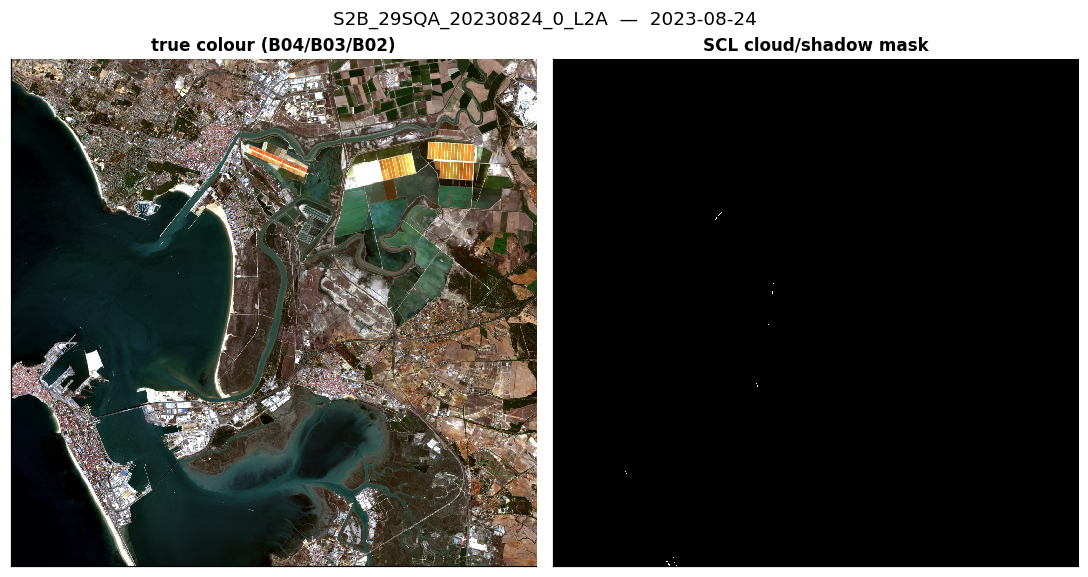

In [5]:
if scene is not None and scene.scl is not None:
    mask = S.cloud_mask(scene.scl)
    print(f"masked fraction: {mask.mean():.2%}\n")
    for name, frac in sorted(S.scl_class_fractions(scene.scl).items(), key=lambda kv: -kv[1]):
        print(f"  {name:<28}{frac:>7.2%}")

    rgb = B.true_color(scene.array)
    fig = V.plot_map_panels({
        "true colour (B04/B03/B02)": ("rgb", rgb),
        "SCL cloud/shadow mask": ("mask", mask.astype(float)),
    }, title=f"{item.id}  —  {str(item.datetime)[:10]}")
    V.save(fig, "05_scene_and_cloudmask")
else:
    mask = None
    print("no SCL available; continuing without a cloud mask")

## The domain shift — the most valuable part of this notebook

**EuroSAT is Level-1C: top-of-atmosphere reflectance.** It is what the sensor
measured, atmosphere included — haze, aerosols, Rayleigh scattering and all.

**Earth Search serves Level-2A: surface reflectance**, with those atmospheric
effects modelled and removed by Sen2Cor.

They are the same units and *not* the same distribution. L2A is systematically
darker in the blue bands (Rayleigh scattering removed) and the two differ in
spread. A model trained on L1C and applied to L2A is operating under a genuine
covariate shift — one that raises no error, produces no warning, and quietly
degrades every prediction.

We do three things about it, in order: **quantify**, **mitigate**, **discuss**.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

blanchon/EuroSAT_MSI: 3 splits ['train', 'test', 'validation'] -> 27,000 chips concatenated
blanchon/EuroSAT_MSI: label mapping {'Annual Crop': 'AnnualCrop', 'Forest': 'Forest', 'Herbaceous Vegetation': 'HerbaceousVegetation', 'Highway': 'Highway', 'Industrial Buildings': 'Industrial', 'Pasture': 'Pasture', 'Permanent Crop': 'PermanentCrop', 'Residential Buildings': 'Residential', 'River': 'River', 'SeaLake': 'SeaLake'}
  converted 5,000/27,000
  converted 10,000/27,000
  converted 15,000/27,000
  converted 20,000/27,000
  converted 25,000/27,000
saved /content/drive/MyDrive/s2-chips-to-map/figures/05_domain_shift_histograms.png
band     EuroSAT L1C mean   scene L2A mean   ratio  std ratio
B01                0.1349           0.0745    0.55       1.68
B02                0.1108           0.0947    0.85       1.67
B03                0.1019           0.1190    1.17       1.74
B04                0.0911           0.1246    1.37       1.67
B05                0.1147           0.1439    1.25   

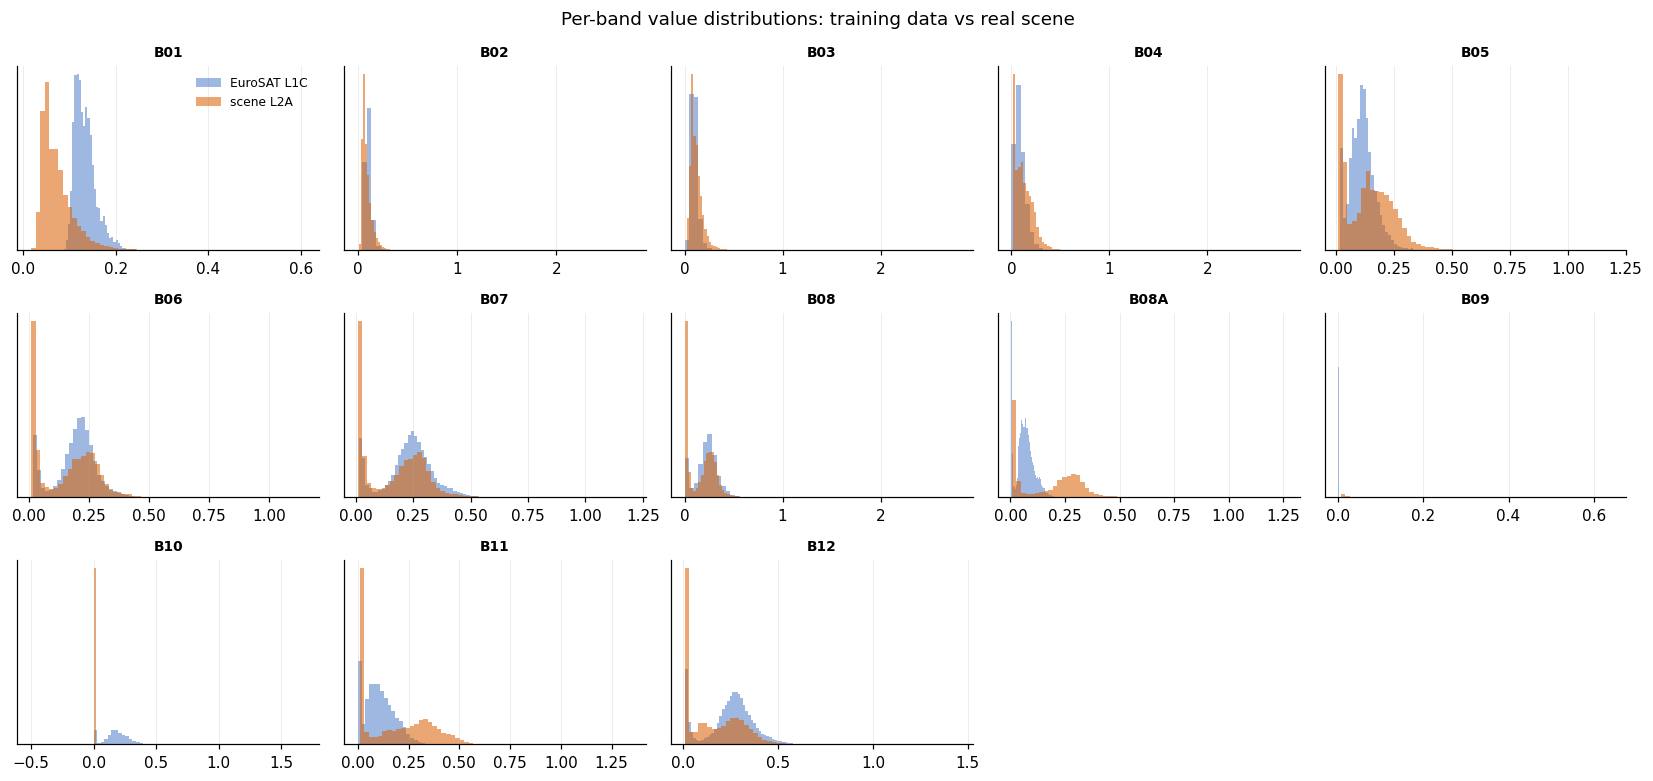

In [6]:
if scene is not None:
    # (a) QUANTIFY: per-band histograms, training chips vs the fetched scene.
    stats = D.load_band_stats()
    splits = D.load_splits()
    bundle = D.load_eurosat_ms()
    rng = np.random.default_rng(cfg.seed)
    sample_idx = np.sort(rng.choice(splits["train"], size=400, replace=False))
    # EuroSAT integers are reflectance x 1e4; put both on the same scale.
    train_block = np.asarray(bundle.X[sample_idx], dtype=np.float32) * 1e-4
    train_samples = [train_block[:, i].ravel() for i in range(13)]

    valid = ~mask if mask is not None else np.ones(scene.shape, bool)
    scene_samples = [scene.array[i][valid].ravel() for i in range(13)]

    fig = V.plot_domain_shift_histograms(train_samples, scene_samples)
    V.save(fig, "05_domain_shift_histograms")

    print(f"{'band':<6}{'EuroSAT L1C mean':>19}{'scene L2A mean':>17}{'ratio':>8}{'std ratio':>11}")
    for i, b in enumerate(B.BAND_IDS):
        tm, ts = float(train_samples[i].mean()), float(train_samples[i].std())
        sm, ss = float(scene_samples[i].mean()), float(scene_samples[i].std())
        print(f"{b:<6}{tm:>19.4f}{sm:>17.4f}{(sm / tm if tm else np.nan):>8.2f}"
              f"{(ss / ts if ts else np.nan):>11.2f}")

**(b) Mitigate.** Two preprocessing options, and we run the classifier under
both:

1. **Training statistics.** Standardise the scene with EuroSAT's per-band
   training mean/std — correct if the distributions matched, which the
   histograms above say they do not.
2. **Scene statistics.** Standardise the scene with its *own* per-band mean/std.
   This absorbs a global L1C→L2A offset for free.

Option 2 is not a free lunch and the assumption should be stated: it assumes the
AOI's land-cover *mix* resembles the training mix. Standardising an all-water
AOI by its own statistics would stretch tiny water-reflectance variations across
the full input range and hand the model noise. It works here because this AOI is
genuinely mixed.

Neither is the real fix, which is (c) below.

In [7]:
if scene is not None:
    train_mean = np.asarray(stats["mean"], np.float32) * 1e-4   # to reflectance units
    train_std = np.asarray(stats["std"], np.float32) * 1e-4
    scene_stats = S.scene_band_stats(scene.array, valid_mask=mask)
    scene_mean = np.asarray(scene_stats["mean"], np.float32)
    scene_std = np.asarray(scene_stats["std"], np.float32)

    normalised = {
        "training stats (naive)": (scene.array - train_mean[:, None, None]) / np.maximum(train_std[:, None, None], 1e-6),
        "scene stats (adapted)": (scene.array - scene_mean[:, None, None]) / np.maximum(scene_std[:, None, None], 1e-6),
    }
    for name, arr in normalised.items():
        print(f"{name:<24} mean {arr.mean():+.3f}  std {arr.std():.3f}  "
              f"range [{arr.min():+.1f}, {arr.max():+.1f}]")
    print("\nA training-standardised scene far from mean 0 / std 1 is the covariate shift,")
    print("expressed in the exact units the network's first layer sees.")

training stats (naive)   mean +27.190  std 122.789  range [-4.8, +1342.7]
scene stats (adapted)    mean +0.000  std 0.961  range [-1.5, +20.5]

A training-standardised scene far from mean 0 / std 1 is the covariate shift,
expressed in the exact units the network's first layer sees.


**(c) Discuss — what the proper fix would be.**

Re-standardising is a patch on a global offset. It cannot repair a shift in the
*shape* of a band's distribution, and it says nothing about the fact that
atmospheric correction changes band *relationships*, not just band means — which
means the spectral indices the model implicitly relies on are shifted too.

The real fixes, in increasing order of effort:

1. **Train on the same processing level you deploy on.** Build the training set
   from L2A chips (BigEarthNet-v2 is L2A, and EuroSAT chips can be regenerated
   from L2A products). This removes the problem instead of managing it.
2. **Apply consistent preprocessing to both sides** — e.g. run the same
   atmospheric correction over the training imagery, or work in an index space
   (NDVI, NDWI) that is far more invariant to atmospheric state than raw bands.
3. **Explicit domain adaptation** — histogram matching, CORAL, or fine-tuning on
   a small labelled sample from the target domain, which links straight back to
   notebook 04's label-efficiency curve: how many target-domain labels would you
   need to buy?

This is exactly the failure mode that breaks production remote-sensing models,
and it is worth treating as a finding rather than an obstacle.

## Sliding-window inference

The model is a *chip* classifier: 64×64 in, one class out. The scene is
~1500×1500. So it is tiled into 64×64 windows with stride 32 (50% overlap), each
window's probability vector is painted across its footprint, and overlapping
windows are averaged.

**Why overlap-and-average.** A window at the edge of an object sees truncated
context and often predicts differently from one containing the object centred.
On a disjoint grid those disagreements land exactly on tile boundaries and the
map comes out visibly blocky. With stride 32, every interior pixel is covered by
four windows with different context, and averaging their probabilities smooths
the seams. It costs 4× the forward passes, which is seconds on a T4.

**What it cannot fix:** the effective resolution is still the tile. A 64×64 chip
classifier can never draw a boundary sharper than ~32 pixels (320 m). That is the
limitation section 05.10 attacks with SAM.

Edge tiles use reflection padding — a zero border is a physically impossible
reflectance and would create a hard artificial edge the model reads as a real
feature. `tests/test_inference.py` asserts that tiling then stitching an array
of any shape reconstructs its exact dimensions, and that a constant model
produces a constant map including at the seams.

In [8]:
import torch

pred_maps, prob_maps = {}, {}
ckpt_path = C.OUTPUT_DIR / "nb02_supervised_backbone_reference.pt"

if scene is not None and ckpt_path.exists():
    ck = torch.load(ckpt_path, map_location="cpu")
    model = M.build_resnet18(13, 10, pretrained=False)
    model.load_state_dict(ck["state_dict"])
    predict_fn = I.torch_predict_fn(model, device=DEVICE, amp=True)

    from tqdm.auto import tqdm
    for name, arr in normalised.items():
        probs = I.sliding_window_predict(arr, predict_fn, num_classes=10,
                                         tile=64, stride=32, batch_size=256, progress=tqdm)
        assert probs.shape[1:] == scene.shape
        prob_maps[name] = probs
        pred_maps[name] = probs.argmax(0).astype(np.uint8)
        print(f"{name:<24} -> map {pred_maps[name].shape}")
elif scene is not None:
    print(f"!! {ckpt_path.name} not found — run notebook 02 first.")

  0%|          | 0/2499 [00:00<?, ?it/s]

training stats (naive)   -> map (1600, 1657)


  0%|          | 0/2499 [00:00<?, ?it/s]

scene stats (adapted)    -> map (1600, 1657)


### How much did the normalisation choice matter?

Two maps of the same pixels from the same weights, differing only in which
statistics standardised the input. The disagreement rate between them *is* the
practical size of the domain-shift problem — with no ground truth needed to
measure it.

In [9]:
if len(pred_maps) == 2:
    a, b = list(pred_maps.values())
    valid = ~mask if mask is not None else np.ones_like(a, bool)
    disagree = float((a[valid] != b[valid]).mean())
    print(f"the two normalisations disagree on {disagree:.1%} of valid pixels\n")
    for name, m in pred_maps.items():
        frac = np.bincount(m[valid], minlength=10) / valid.sum()
        top = np.argsort(frac)[::-1][:4]
        print(f"{name:<24}" + "  ".join(f"{C.CLASS_NAMES[i]} {frac[i]:.1%}" for i in top))
    print("\nA plausibility check without labels: does the class mix match what the "
          "true-colour image obviously contains? An AOI that is half sea should predict "
          "a lot of SeaLake.")

the two normalisations disagree on 65.1% of valid pixels

training stats (naive)  Residential 80.8%  SeaLake 16.0%  Industrial 3.0%  River 0.2%
scene stats (adapted)   Residential 25.4%  SeaLake 17.7%  River 16.8%  Pasture 12.1%

A plausibility check without labels: does the class mix match what the true-colour image obviously contains? An AOI that is half sea should predict a lot of SeaLake.


### The map, and the georeferenced output

**A PNG is a picture; a GeoTIFF is a map.** Carrying the CRS and affine transform
through from the source imagery means the output can be opened in QGIS, overlaid
on cadastral or protected-area boundaries, intersected with other layers, and
have real areas computed from it. That is what makes this geospatial work rather
than image processing.

Cloud-masked pixels are written as nodata (255) rather than as a class:
predicting land cover under a cloud is not a prediction, it is a guess about the
cloud.

In [10]:
if pred_maps:
    chosen_name = "scene stats (adapted)" if "scene stats (adapted)" in pred_maps else list(pred_maps)[0]
    class_map = pred_maps[chosen_name].copy()
    if mask is not None:
        class_map = I.apply_mask(class_map, mask, fill=255)

    out_path = I.write_geotiff(
        C.OUTPUT_DIR / "landcover_prediction.tif", class_map,
        scene.transform, scene.crs, dtype="uint8", nodata=255, class_names=C.CLASS_NAMES,
    )
    print("wrote", out_path)

    # Also save the per-pixel confidence (max averaged probability). Notebook 06
    # compares this distribution against the model's confidence on benchmark
    # chips — which is how you detect that a shift has broken your confidence
    # signal without owning a single ground-truth label for the scene.
    conf_map = prob_maps[chosen_name].max(0).astype(np.float32)
    I.write_geotiff(C.OUTPUT_DIR / "prediction_confidence.tif", conf_map,
                    scene.transform, scene.crs, dtype="float32", nodata=None)
    valid_pixels = ~mask if mask is not None else np.ones(scene.shape, bool)
    print(f"mean prediction confidence over valid pixels: {float(conf_map[valid_pixels].mean()):.3f}")

    areas = I.class_areas(class_map, C.CLASS_NAMES, pixel_size_m=10.0)
    print(f"\n{'class':<24}{'hectares':>12}{'% of valid':>12}")
    for name in C.CLASS_NAMES:
        print(f"{name:<24}{areas[name]['hectares']:>12,.0f}{areas[name]['fraction']:>12.1%}")
    print(f"{'(cloud/nodata)':<24}{areas['_nodata']['hectares']:>12,.0f}")

    E.append_result({
        "notebook": "05", "arm": "scene_inference",
        "input": "Sentinel-2 L2A, 13 bands (B10 absent)",
        "aoi": AOI["name"], "bbox": list(BBOX), "item_id": item.id,
        "scene_datetime": str(item.datetime), "cloud_cover": float(item.properties.get("eo:cloud_cover", -1)),
        "normalisation": chosen_name,
        "normalisation_disagreement": disagree if len(pred_maps) == 2 else None,
        "areas_hectares": {k: v["hectares"] for k, v in areas.items()},
        "notes": "EuroSAT-trained (L1C) model applied to L2A — covariate shift, no ground truth here",
    })

wrote /content/drive/MyDrive/s2-chips-to-map/outputs/landcover_prediction.tif
mean prediction confidence over valid pixels: 0.729

class                       hectares  % of valid
AnnualCrop                     1,564        5.9%
Forest                             0        0.0%
HerbaceousVegetation             410        1.5%
Highway                          546        2.1%
Industrial                     1,775        6.7%
Pasture                        3,215       12.1%
PermanentCrop                  3,123       11.8%
Residential                    6,724       25.4%
River                          4,452       16.8%
SeaLake                        4,700       17.7%
(cloud/nodata)                     3


The map itself, beside the imagery it came from and the mask that says which
parts of it to disbelieve. Showing all three together is the honest presentation:
a land-cover map shown alone invites the reader to trust every pixel equally.

saved /content/drive/MyDrive/s2-chips-to-map/figures/05_landcover_map.png


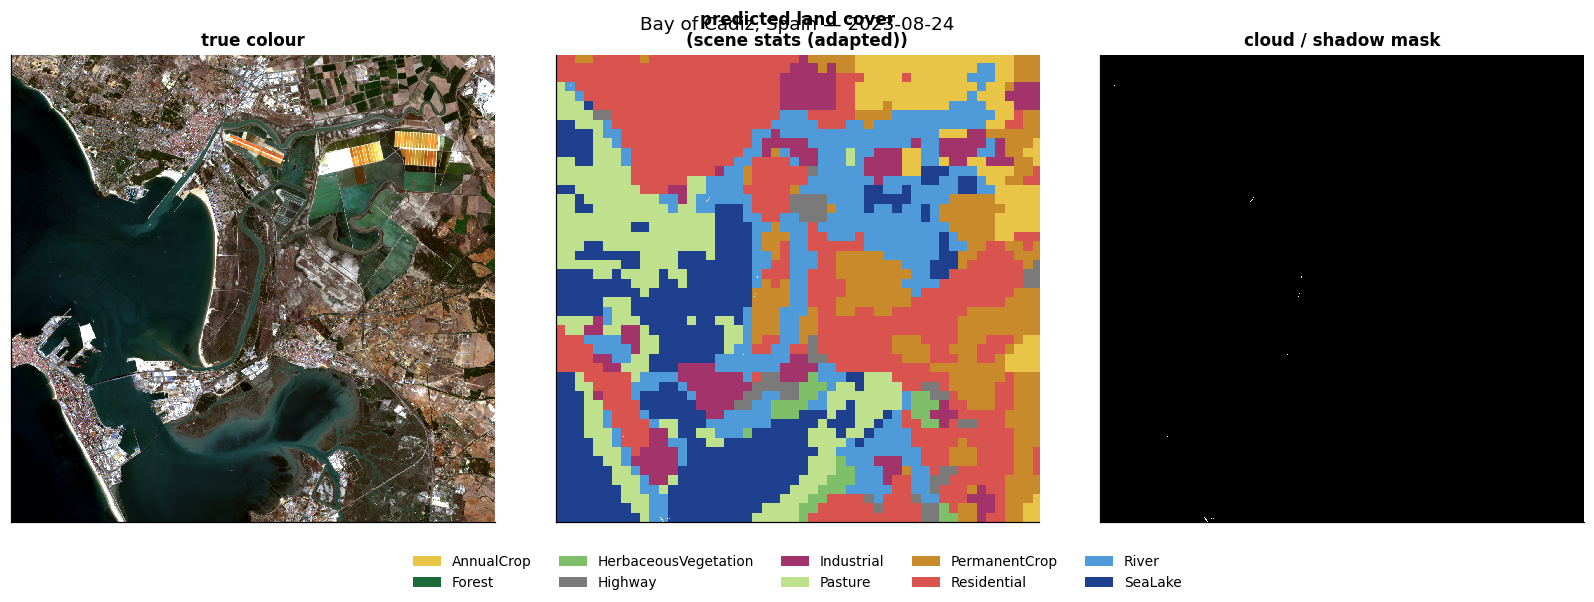

In [11]:
if pred_maps:
    panels = {"true colour": ("rgb", B.true_color(scene.array)),
              f"predicted land cover\n({chosen_name})": ("classes", class_map)}
    if mask is not None:
        panels["cloud / shadow mask"] = ("mask", mask.astype(float))
    fig = V.plot_map_panels(panels, title=f"{AOI['name']} — {str(item.datetime)[:10]}")
    V.save(fig, "05_landcover_map")

## Segment Anything: crisp boundaries without semantics

The classifier's weakness is now visible in the map — its boundaries are
quantised to the tile grid. SAM has the complementary property: it produces
crisp, object-aligned segments with **no idea what any of them are**.

Three steps:

**(a) Automatic mask generation** on the RGB rendering — object-like segments
with no labels and no training.

**(b) Text-prompted segmentation** via LangSAM / Grounding DINO: "forest",
"water", "buildings", "farmland".

**(c) The combination** — use SAM's segments as superpixels and give each one the
majority class the classifier predicted inside it. Crisp boundaries *and*
semantics, with no training and no new model. It is a simple idea, and being able
to reason about *combining* models rather than just running them is the point of
including it.

`segment-geospatial` and `groundingdino-py` are heavy and build a CUDA
extension, so the install is wrapped: if it fails, this section is skipped and
says so, and the rest of the notebook stands on its own.

In [12]:
SAM_OK = False
try:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "segment-geospatial"], check=True)
    from samgeo import SamGeo
    SAM_OK = True
    print("segment-geospatial installed")
except Exception as exc:
    print("!! segment-geospatial unavailable:", type(exc).__name__, exc)
    print("!! skipping section 05.10; the fallback (plain SAM automatic masks) also needs this package.")

segment-geospatial installed


**(a) Automatic mask generation.** SAM is run on the true-colour rendering of the
scene — it is an RGB model, so this is another place where ten bands are
discarded. It returns a segmentation with no class labels at all: pure geometry.

In [13]:
segments = None
if SAM_OK and pred_maps:
    from PIL import Image
    rgb_path = C.OUTPUT_DIR / "scene_rgb.tif"
    rgb8 = (B.true_color(scene.array) * 255).astype(np.uint8)
    I.write_geotiff(rgb_path, np.transpose(rgb8, (2, 0, 1)), scene.transform, scene.crs,
                    dtype="uint8", nodata=None)

    try:
        sam = SamGeo(model_type="vit_h", automatic=True, sam_kwargs=None)
        sam.generate(str(rgb_path), output=str(C.OUTPUT_DIR / "sam_masks.tif"), unique=True)
        import rasterio
        with rasterio.open(C.OUTPUT_DIR / "sam_masks.tif") as src:
            segments = src.read(1)
        print("SAM produced", len(np.unique(segments)), "segments")
    except Exception as exc:
        print("!! SAM automatic mask generation failed:", type(exc).__name__, exc)

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:22<00:00, 112MB/s]


SAM produced 140 segments


**(c) The combination.** Every SAM segment takes the majority class the
classifier predicted inside it. No training, no new model — just each model doing
the half of the job it is good at. The four-panel figure below is the one that
belongs in the README.

(Text-prompted segmentation, step (b), needs `groundingdino-py`, which builds a
CUDA extension and is the most fragile install in this project. It is left out of
the automatic path deliberately; the automatic-mask route above is the documented
fallback and it is what produces the combination here.)

saved /content/drive/MyDrive/s2-chips-to-map/figures/05_sam_combination.png
segment majority vote changed 54.0% of valid pixels


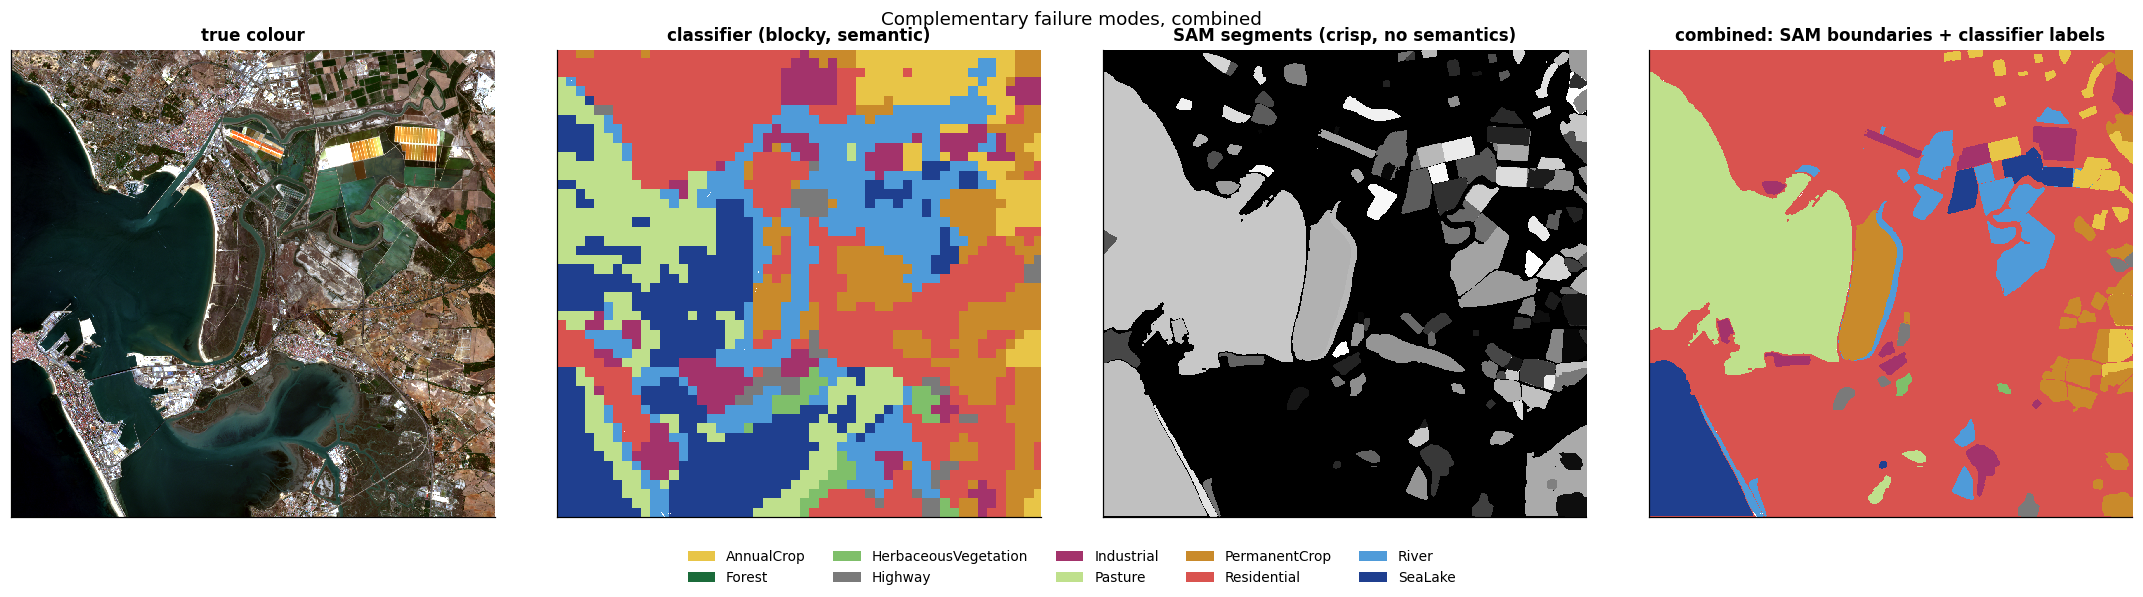

In [14]:
if segments is not None:
    combined = I.majority_vote_by_segment(class_map, segments, num_classes=10, nodata=255)
    if mask is not None:
        combined = I.apply_mask(combined, mask, fill=255)

    I.write_geotiff(C.OUTPUT_DIR / "landcover_prediction_sam.tif", combined,
                    scene.transform, scene.crs, class_names=C.CLASS_NAMES)

    fig = V.plot_map_panels({
        "true colour": ("rgb", B.true_color(scene.array)),
        "classifier (blocky, semantic)": ("classes", class_map),
        "SAM segments (crisp, no semantics)": ("mask", (segments % 37).astype(float)),
        "combined: SAM boundaries + classifier labels": ("classes", combined),
    }, title="Complementary failure modes, combined")
    V.save(fig, "05_sam_combination")

    valid = ~mask if mask is not None else np.ones_like(class_map, bool)
    print(f"segment majority vote changed {float((combined[valid] != class_map[valid]).mean()):.1%} of valid pixels")

**Honest analysis of the combination.** SAM produces crisp, well-delineated
boundaries but has no semantic understanding of land cover. The classifier
produces semantics with boundaries blurred to the 64×64 tile scale. They fail in
complementary ways, and the majority-vote combination inherits the strengths of
both — but also inherits SAM's mistakes: where SAM merges a field and the road
beside it into one segment, the majority vote erases the road entirely. The
combination is sharper, not necessarily more accurate, and without ground truth
here we can only report the disagreement rate, not an improvement.

## Independent sanity check: ESA WorldCover

**This is an agreement analysis, not an accuracy evaluation.** ESA WorldCover is
an independently produced 10 m land-cover product — another model's output, not
ground truth. Where we disagree with it, either of us could be wrong. Being
precise about that distinction matters: presenting agreement with WorldCover as
"accuracy" would silently promote one map to truth.

The class schemes also do not align one-to-one. WorldCover has no Highway,
Industrial or Residential — it has a single Built-up class — and no distinction
between annual and permanent cropland. The mapping below is lossy and its
imperfections are documented rather than smoothed over.

Optional section: if the fetch is awkward, it is skipped gracefully.

In [15]:
# ESA WorldCover 2021 v200, hosted as public COGs on AWS (CC-BY 4.0).
# Tiles are 3x3 degrees, named by their south-west corner.
WORLDCOVER_CLASSES = {10: "Tree cover", 20: "Shrubland", 30: "Grassland", 40: "Cropland",
                      50: "Built-up", 60: "Bare / sparse", 70: "Snow and ice",
                      80: "Permanent water", 90: "Herbaceous wetland", 95: "Mangroves",
                      100: "Moss and lichen"}
# Lossy by construction: WorldCover has one Built-up class where EuroSAT has three,
# and no annual/permanent cropland split.
EUROSAT_TO_WORLDCOVER = {
    "AnnualCrop": 40, "PermanentCrop": 40, "Forest": 10, "HerbaceousVegetation": 30,
    "Pasture": 30, "Highway": 50, "Industrial": 50, "Residential": 50,
    "River": 80, "SeaLake": 80,
}

wc = None
if scene is not None:
    try:
        import rasterio
        lon = int(np.floor(BBOX[0] / 3) * 3)
        lat = int(np.floor(BBOX[1] / 3) * 3)
        tile = f"{'S' if lat < 0 else 'N'}{abs(lat):02d}{'W' if lon < 0 else 'E'}{abs(lon):03d}"
        url = ("https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/"
               f"ESA_WorldCover_10m_2021_v200_{tile}_Map.tif")
        print("attempting", url)
        wc, _, _ = S.read_window(url, BBOX, target_shape=scene.shape, resampling="nearest")
        print("WorldCover window", wc.shape, "classes present:",
              [WORLDCOVER_CLASSES.get(int(c), c) for c in np.unique(wc)])
    except Exception as exc:
        print("!! WorldCover unavailable:", type(exc).__name__, exc)
        print("!! skipping the agreement analysis — it is optional.")

attempting https://esa-worldcover.s3.eu-central-1.amazonaws.com/v200/2021/map/ESA_WorldCover_10m_2021_v200_N36W009_Map.tif
WorldCover window (1600, 1657) classes present: ['Tree cover', 'Shrubland', 'Grassland', 'Cropland', 'Built-up', 'Bare / sparse', 'Permanent water', 'Herbaceous wetland']


Map both products into WorldCover's coarser scheme and cross-tabulate. Note what
the mapping destroys: our three built-up classes collapse into one, so a
Residential-vs-Industrial error becomes invisible here, and our Annual/Permanent
crop distinction disappears entirely. Agreement computed after a lossy mapping is
systematically *higher* than the underlying maps deserve, which is one more
reason not to read this number as accuracy.

overall agreement after mapping to the WorldCover scheme: 42.8%
(agreement with an independent product, NOT accuracy — neither map is ground truth)
saved /content/drive/MyDrive/s2-chips-to-map/figures/05_worldcover_agreement.png


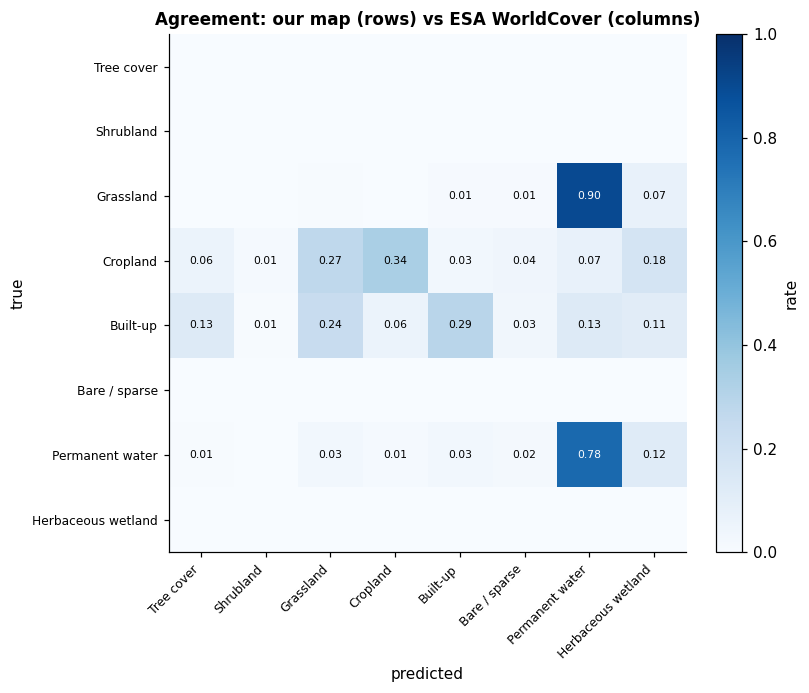

In [16]:
if wc is not None and pred_maps:
    ours_wc = np.full(class_map.shape, 255, np.uint8)
    wc_codes = sorted(WORLDCOVER_CLASSES)
    code_to_idx = {c: i for i, c in enumerate(wc_codes)}
    for i, name in enumerate(C.CLASS_NAMES):
        ours_wc[class_map == i] = code_to_idx[EUROSAT_TO_WORLDCOVER[name]]
    theirs = np.full(wc.shape, 255, np.uint8)
    for c, i in code_to_idx.items():
        theirs[wc == c] = i

    valid = (ours_wc != 255) & (theirs != 255)
    if mask is not None:
        valid &= ~mask
    agree = float((ours_wc[valid] == theirs[valid]).mean())
    print(f"overall agreement after mapping to the WorldCover scheme: {agree:.1%}")
    print("(agreement with an independent product, NOT accuracy — neither map is ground truth)")

    A = I.agreement_matrix(ours_wc[valid], theirs[valid], len(wc_codes), len(wc_codes))
    keep = [i for i in range(len(wc_codes)) if A[i].sum() or A[:, i].sum()]
    names = [WORLDCOVER_CLASSES[wc_codes[i]] for i in keep]
    fig = V.plot_confusion_matrix(A[np.ix_(keep, keep)], names, normalize=True,
                                  title="Agreement: our map (rows) vs ESA WorldCover (columns)")
    V.save(fig, "05_worldcover_agreement")

    E.append_result({"notebook": "05", "arm": "worldcover_agreement",
                     "overall_agreement": agree,
                     "notes": "agreement with an independent product, not accuracy; "
                              "class schemes mapped lossily (3 EuroSAT built classes -> 1)"})

## Findings

_Fill in from the run. The expected outcome is degradation, and that is the
interesting result — say so plainly._

1. **The pipeline works end to end**: STAC search → windowed COG reads →
   resampled 13-band stack → cloud mask → sliding-window inference →
   georeferenced GeoTIFF with per-class areas in hectares.

2. **The L1C→L2A shift is real and measurable.** The per-band histograms show it,
   and the two normalisation choices disagree on a substantial fraction of
   pixels — from identical weights on identical pixels. Nothing in the pipeline
   raises an error; the map simply gets worse.

3. **Re-standardising with scene statistics is a patch, not a fix.** It absorbs
   a global offset and assumes the AOI's land-cover mix resembles training. The
   real fix is to train on the processing level you deploy on.

4. **The map's honest weaknesses**: boundaries quantised to the tile scale;
   linear features (Highway, River) badly served by a 640 m chip classifier;
   classes EuroSAT never contained simply do not exist in the output — the model
   must assign one of its ten labels to every pixel, including surfaces it has
   never seen.

5. **SAM + classifier is sharper, not provably better.** Complementary failure
   modes combine well, but without ground truth we report the disagreement rate,
   not an improvement.

6. **Agreement with WorldCover is an agreement number**, not an accuracy number,
   and the class-scheme mapping is lossy by construction.

**Next:** notebook 06 asks whether the model's confidence can be trusted — on the
benchmark and under this shift.